# 1. Import and Install Dependencies

In [ ]:
!pip install tensorflow==2.14.1 opencv-python mediapipe scikit-learn matplotlib

In [2]:
import cv2
import numpy as np
import os
from matplotlib import pyplot as plt
import time
import mediapipe as mp

# 2. Keypoints using MP Holistic

In [4]:
mp_holistic = mp.solutions.holistic # Holistic model
mp_drawing = mp.solutions.drawing_utils # Drawing utilities

In [5]:
def mediapipe_detection(image, model):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # COLOR CONVERSION BGR 2 RGB
    image.flags.writeable = False                  # Image is no longer writeable
    results = model.process(image)                 # Make prediction
    image.flags.writeable = True                   # Image is now writeable 
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR) # COLOR COVERSION RGB 2 BGR
    return image, results

In [6]:
def draw_landmarks(image, results):
    # Pose
    mp_drawing.draw_landmarks(
        image,
        results.pose_landmarks,
        mp_holistic.POSE_CONNECTIONS
    )

    # Left Hand
    mp_drawing.draw_landmarks(
        image,
        results.left_hand_landmarks,
        mp_holistic.HAND_CONNECTIONS
    )

    # Right Hand
    mp_drawing.draw_landmarks(
        image,
        results.right_hand_landmarks,
        mp_holistic.HAND_CONNECTIONS
    )


In [7]:
def draw_styled_landmarks(image, results):
   # Pose
    mp_drawing.draw_landmarks(
        image,
        results.pose_landmarks,
        mp_holistic.POSE_CONNECTIONS,
        mp_drawing.DrawingSpec(color=(80,22,10), thickness=2, circle_radius=4),
        mp_drawing.DrawingSpec(color=(80,44,121), thickness=2, circle_radius=2)
    )

    # Left Hand
    mp_drawing.draw_landmarks(
        image,
        results.left_hand_landmarks,
        mp_holistic.HAND_CONNECTIONS,
        mp_drawing.DrawingSpec(color=(121,22,76), thickness=2, circle_radius=4),
        mp_drawing.DrawingSpec(color=(121,44,250), thickness=2, circle_radius=2)
    )

    # Right Hand
    mp_drawing.draw_landmarks(
        image,
        results.right_hand_landmarks,
        mp_holistic.HAND_CONNECTIONS,
        mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4),
        mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2)
    )


In [12]:
cap = cv2.VideoCapture(0)
# Set mediapipe model 
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    while cap.isOpened():

        # Read feed
        ret, frame = cap.read()

        # Make detections
        image, results = mediapipe_detection(frame, holistic)
        print(results)
        
        # Draw landmarks
        draw_styled_landmarks(image, results)

        # Show to screen
        cv2.imshow('OpenCV Feed', image)

        # Break gracefully
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break
    cap.release()
    cv2.destroyAllWindows()

<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.soluti

In [14]:
draw_landmarks(frame, results)

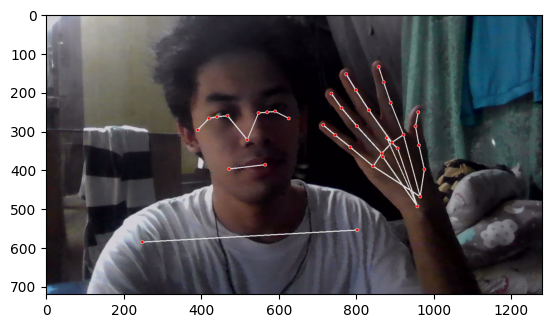

In [15]:
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

# 3. Extract Keypoint Values

In [16]:
len(results.left_hand_landmarks.landmark)

21

In [17]:
pose = []
for res in results.pose_landmarks.landmark:
    test = np.array([res.x, res.y, res.z, res.visibility])
    pose.append(test)

In [18]:
pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(132)
lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)

In [19]:
def extract_keypoints(results):
    pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(33*4)
    lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
    rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)
    return np.concatenate([pose, lh, rh])

In [20]:
result_test = extract_keypoints(results)

In [21]:
result_test

array([ 4.05612320e-01,  4.49271262e-01, -6.67832494e-01,  9.99981761e-01,
        4.28171337e-01,  3.53321642e-01, -6.30392492e-01,  9.99952495e-01,
        4.45599645e-01,  3.50302577e-01, -6.29841208e-01,  9.99956667e-01,
        4.61729378e-01,  3.47441584e-01, -6.29299045e-01,  9.99953926e-01,
        3.66387188e-01,  3.63070130e-01, -6.27960801e-01,  9.99960124e-01,
        3.44670236e-01,  3.66730750e-01, -6.26847804e-01,  9.99959052e-01,
        3.28138649e-01,  3.72285128e-01, -6.26866460e-01,  9.99956846e-01,
        4.89123166e-01,  3.72693896e-01, -3.49077553e-01,  9.99946535e-01,
        3.05897325e-01,  4.15215045e-01, -3.20127189e-01,  9.99968827e-01,
        4.42040771e-01,  5.37605703e-01, -5.58099389e-01,  9.99969900e-01,
        3.69126022e-01,  5.52926302e-01, -5.52261949e-01,  9.99976873e-01,
        6.27739072e-01,  7.71193624e-01, -1.55096307e-01,  9.99675870e-01,
        1.94189727e-01,  8.13890934e-01, -1.12736329e-01,  9.99583602e-01,
        8.32759023e-01,  

In [22]:
np.save('0', result_test)

In [23]:
np.load('0.npy')

array([ 4.05612320e-01,  4.49271262e-01, -6.67832494e-01,  9.99981761e-01,
        4.28171337e-01,  3.53321642e-01, -6.30392492e-01,  9.99952495e-01,
        4.45599645e-01,  3.50302577e-01, -6.29841208e-01,  9.99956667e-01,
        4.61729378e-01,  3.47441584e-01, -6.29299045e-01,  9.99953926e-01,
        3.66387188e-01,  3.63070130e-01, -6.27960801e-01,  9.99960124e-01,
        3.44670236e-01,  3.66730750e-01, -6.26847804e-01,  9.99959052e-01,
        3.28138649e-01,  3.72285128e-01, -6.26866460e-01,  9.99956846e-01,
        4.89123166e-01,  3.72693896e-01, -3.49077553e-01,  9.99946535e-01,
        3.05897325e-01,  4.15215045e-01, -3.20127189e-01,  9.99968827e-01,
        4.42040771e-01,  5.37605703e-01, -5.58099389e-01,  9.99969900e-01,
        3.69126022e-01,  5.52926302e-01, -5.52261949e-01,  9.99976873e-01,
        6.27739072e-01,  7.71193624e-01, -1.55096307e-01,  9.99675870e-01,
        1.94189727e-01,  8.13890934e-01, -1.12736329e-01,  9.99583602e-01,
        8.32759023e-01,  

# 4. Setup Folders for Collection

In [24]:
import shutil
shutil.rmtree('MP_Data', ignore_errors=True)

In [25]:
# Path for exported data, numpy arrays
DATA_PATH = os.path.join('MP_Data') 

# Actions that we try to detect
actions = np.array(['kamusta', 'salamat', 'mahalkita', 'oo', 'hindi'])

# Thirty videos worth of data
no_sequences = 30

# Videos are going to be 30 frames in length
sequence_length = 30

# Folder start
start_folder = 0

In [26]:
for action in actions:
    action_path = os.path.join(DATA_PATH, action)
    for sequence in range(no_sequences):
        os.makedirs(os.path.join(action_path, str(sequence)), exist_ok=True)

# 5. Collect Keypoint Values for Training and Testing

In [27]:
import time

def record_action(action, cap, holistic):
    for sequence in range(no_sequences):
        for frame_num in range(sequence_length):

            ret, frame = cap.read()
            image, results = mediapipe_detection(frame, holistic)
            draw_styled_landmarks(image, results)

            if frame_num == 0:
                cv2.putText(image, 'STARTING COLLECTION', (120, 200),
                            cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 4, cv2.LINE_AA)
                cv2.putText(image, 'Collecting frames for {} Video Number {}'.format(action, sequence), (15, 12),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1, cv2.LINE_AA)
                cv2.imshow('OpenCV Feed', image)
                cv2.waitKey(2000)
            else:
                cv2.putText(image, 'Collecting frames for {} Video Number {}'.format(action, sequence), (15, 12),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1, cv2.LINE_AA)
                cv2.imshow('OpenCV Feed', image)

            keypoints = extract_keypoints(results)
            sequence_dir = os.path.join(DATA_PATH, action, str(sequence))
            os.makedirs(sequence_dir, exist_ok=True)
            npy_path = os.path.join(sequence_dir, str(frame_num))
            np.save(npy_path, keypoints)

            key = cv2.waitKey(10) & 0xFF

            if key == ord('e'):
                while True:
                    ret, pause_frame = cap.read()
                    cv2.putText(pause_frame, 'PAUSED - press E to resume', (60, 240),
                                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 165, 255), 3, cv2.LINE_AA)
                    cv2.imshow('OpenCV Feed', pause_frame)
                    resume_key = cv2.waitKey(10) & 0xFF
                    if resume_key == ord('e'):
                        break
                    if resume_key == ord('q'):
                        return "stopped"

                for countdown in range(5, 0, -1):
                    ret, cd_frame = cap.read()
                    cv2.putText(cd_frame, f'Resuming in {countdown}...', (100, 240),
                                cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 255, 0), 3, cv2.LINE_AA)
                    cv2.imshow('OpenCV Feed', cd_frame)
                    cv2.waitKey(1000)

            if key == ord('q'):
                return "stopped"

    return "done"

In [28]:
cap = cv2.VideoCapture(0)
holistic_ctx = mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5)
holistic = holistic_ctx.__enter__()

In [29]:
record_action('kamusta', cap, holistic)

'done'

In [30]:
record_action('salamat', cap, holistic)

'done'

In [31]:
record_action('mahalkita', cap, holistic)

'done'

In [32]:
record_action('oo', cap, holistic)

'done'

In [33]:
record_action('hindi', cap, holistic)

'done'

In [34]:
holistic_ctx.__exit__(None, None, None)
cap.release()
cv2.destroyAllWindows()

In [35]:
cap.release()
cv2.destroyAllWindows()

# 6. Preprocess Data and Create Labels and Features

In [36]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

In [37]:
label_map = {label:num for num, label in enumerate(actions)}

In [38]:
label_map

{'kamusta': 0, 'salamat': 1, 'mahalkita': 2, 'oo': 3, 'hindi': 4}

In [39]:
sequences, labels = [], []
for action in actions:
    for sequence in range(no_sequences):
        window = []
        for frame_num in range(sequence_length):
            res = np.load(os.path.join(DATA_PATH, action, str(sequence), "{}.npy".format(frame_num)))
            window.append(res)
        sequences.append(window)
        labels.append(label_map[action])

In [40]:
np.array(sequences).shape

(150, 30, 258)

In [41]:
np.array(labels).shape

(150,)

In [42]:
X = np.array(sequences)

In [43]:
X.shape

(150, 30, 258)

In [44]:
y = to_categorical(labels).astype(int)

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [46]:
y_test.shape

(30, 5)

# 7. Build and Train LSTM Neural Network

In [47]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping

In [48]:
log_dir = os.path.join('Logs')
tb_callback = TensorBoard(log_dir=log_dir)
early_stop = EarlyStopping(monitor='val_categorical_accuracy', patience=100, restore_best_weights=True)

In [49]:
model = Sequential()
model.add(LSTM(64, return_sequences=True, activation='relu', input_shape=(30,258)))
model.add(LSTM(128, return_sequences=True, activation='relu'))
model.add(LSTM(64, return_sequences=False, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(actions.shape[0], activation='softmax'))

In [50]:
model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['categorical_accuracy'])

In [51]:
model.fit(X_train, y_train, epochs=2000, validation_data=(X_test, y_test), callbacks=[tb_callback, early_stop])

Epoch 1/2000
4/4 [==============================] - 13s 543ms/step - loss: 1.5917 - categorical_accuracy: 0.2833 - val_loss: 1.4934 - val_categorical_accuracy: 0.4000
Epoch 2/2000
4/4 [==============================] - 0s 85ms/step - loss: 1.4403 - categorical_accuracy: 0.3917 - val_loss: 1.1575 - val_categorical_accuracy: 0.5000
Epoch 3/2000
4/4 [==============================] - 0s 81ms/step - loss: 1.1512 - categorical_accuracy: 0.4833 - val_loss: 1.0826 - val_categorical_accuracy: 0.4333
Epoch 4/2000
4/4 [==============================] - 0s 88ms/step - loss: 1.0663 - categorical_accuracy: 0.5167 - val_loss: 1.4346 - val_categorical_accuracy: 0.3333
Epoch 5/2000
4/4 [==============================] - 0s 89ms/step - loss: 1.1986 - categorical_accuracy: 0.4333 - val_loss: 0.9578 - val_categorical_accuracy: 0.6000
Epoch 6/2000
4/4 [==============================] - 0s 85ms/step - loss: 1.1082 - categorical_accuracy: 0.4833 - val_loss: 0.8268 - val_categorical_accuracy: 0.5333
Epoch 7/

In [52]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 30, 64)            82688     
                                                                 
 lstm_1 (LSTM)               (None, 30, 128)           98816     
                                                                 
 lstm_2 (LSTM)               (None, 64)                49408     
                                                                 
 dense (Dense)               (None, 64)                4160      
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 5)                 165       
                                                                 
Total params: 237317 (927.02 KB)
Trainable params: 23731

# 8. Make Predictions

In [53]:
res = model.predict(X_test)

1/1 [==============================] - 1s 801ms/step


In [62]:
actions[np.argmax(res[3])]

'salamat'

In [63]:
actions[np.argmax(y_test[3])]

'salamat'

# 9. Save Weights

In [64]:
model.save('action.h5')
model.save('action.keras')

C:\Users\user\anaconda3\envs\tensorflow_2\lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [65]:
import json
with open('labels.json', 'w') as f:
    json.dump(actions.tolist(), f)
    config = {
    "sequence_length": sequence_length,
    "num_features": 258,
    "threshold": 0.7
}
with open('config.json', 'w') as f:
    json.dump(config, f)

In [ ]:
del model

In [66]:
model.load_weights('action.h5')

# 10. Evaluation using Confusion Matrix and Accuracy

In [67]:
from sklearn.metrics import multilabel_confusion_matrix, accuracy_score

In [68]:
yhat = model.predict(X_train)

4/4 [==============================] - 0s 23ms/step


In [69]:
ytrue = np.argmax(y_train, axis=1).tolist()
yhat = np.argmax(yhat, axis=1).tolist()

In [70]:
multilabel_confusion_matrix(ytrue, yhat)

array([[[96,  0],
        [ 0, 24]],

       [[96,  0],
        [ 0, 24]],

       [[96,  0],
        [ 2, 22]],

       [[89,  7],
        [ 0, 24]],

       [[94,  2],
        [ 7, 17]]], dtype=int64)

In [71]:
accuracy_score(ytrue, yhat)

0.925

# 11. Test in Real Time

In [72]:
from scipy import stats

In [73]:
colors = [(245,117,16), (117,245,16), (16,117,245)]

res = res.flatten()

def prob_viz(res, actions, input_frame, colors):
    output_frame = input_frame.copy()
    # Clip loop to the shortest length to avoid index errors
    for num, prob in enumerate(res[:len(actions)]):
        cv2.rectangle(
            output_frame,
            (0, 60 + num*40),
            (int(prob * 100), 90 + num*40),
            colors[num % len(colors)],  # cycle colors if fewer than actions
            -1
        )
        cv2.putText(
            output_frame,
            actions[num],
            (0, 85 + num*40),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (255,255,255),
            2,
            cv2.LINE_AA
        )
    return output_frame

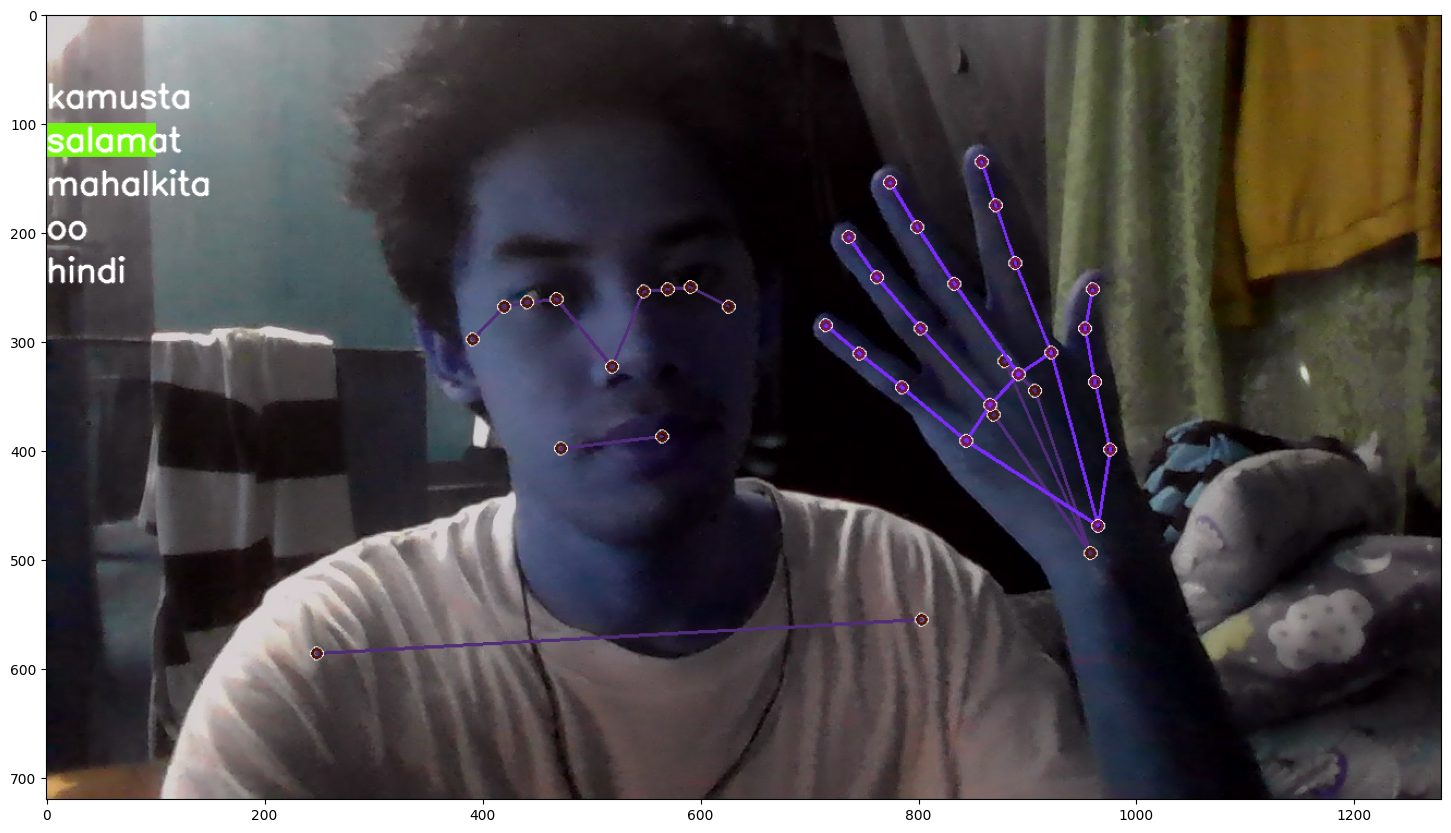

In [74]:
plt.figure(figsize=(18,18))
plt.imshow(prob_viz(res, actions, image, colors))

In [75]:
sequence = [] 
sentence = [] 
predictions = [] 
threshold = 0.7
cap = cv2.VideoCapture(0)
#Set mediapipe model
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic: 
    while cap.isOpened():
        # Read feed
        ret, frame = cap.read()
    
        # Make detections
        image, results = mediapipe_detection(frame, holistic)
        print(results)
        
        # Draw landmarks
        draw_styled_landmarks(image, results)
        
        # 2. Prediction logic
        keypoints = extract_keypoints(results)
        sequence.append(keypoints)
        sequence = sequence[-30:]
        
        if len(sequence) == 30:
            res = model.predict(np.expand_dims(sequence, axis=0))[0]
            print(actions[np.argmax(res)])
            predictions.append(np.argmax(res))
            
            
        #3. Viz logic
            if np.unique(predictions[-10:])[0]==np.argmax(res): 
                if res[np.argmax(res)] > threshold: 
                    
                    if len(sentence) > 0: 
                        if actions[np.argmax(res)] != sentence[-1]:
                            sentence.append(actions[np.argmax(res)])
                    else:
                        sentence.append(actions[np.argmax(res)])
    
            if len(sentence) > 5: 
                sentence = sentence[-5:]
    
            # Viz probabilities
            image = prob_viz(res, actions, image, colors)
            
        cv2.rectangle(image, (0,0), (640, 40), (245, 117, 16), -1)
        cv2.putText(image, ' '.join(sentence), (3,30), 
                       cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA)
        
        # Show to screen
        cv2.imshow('OpenCV Feed', image)
    
        # Break gracefully
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break
    cap.release()
    cv2.destroyAllWindows()

<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.soluti

In [76]:
import tensorflow as tf

test_model = tf.keras.models.load_model('action.h5')
test_model.summary()

dummy_input = np.random.rand(1, 30, 258).astype('float32')
prediction = test_model.predict(dummy_input)
print(prediction)
print(actions[np.argmax(prediction)])

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 30, 64)            82688     
                                                                 
 lstm_1 (LSTM)               (None, 30, 128)           98816     
                                                                 
 lstm_2 (LSTM)               (None, 64)                49408     
                                                                 
 dense (Dense)               (None, 64)                4160      
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 5)                 165       
                                                                 
Total params: 237317 (927.02 KB)
Trainable params: 23731